# 🧪 Evaluador Avanzado de Arquitecturas Cloud (Cloudscape Benchmark)

Este Jupyter Notebook proporciona un marco de evaluación completo y flexible para analizar los grafos de arquitectura generados por los modelos (**Estándar** y **Parsimonioso**) en comparación con el **Ground Truth** manual del dataset Cloudscape.

---

## 📌 Algoritmo y Métricas de Evaluación Utilizadas

### 1. Métricas de Servicios (Nodos)
* **F1 Servicios Únicos (`svc_f1`)**: Evalúa el conjunto de tipos de servicios únicos presentes en la arquitectura (ej. Redshift, S3, EC2). $F1 = \frac{2 \cdot P \cdot R}{P + R}$.
* **F1 Multiset / Nodos Reales (`ms_f1`)**: Considera la multiplicidad de servicios (ej. si hay 2 Lambdas en el Ground Truth y el modelo genera 1, se penaliza mediante la intersección de multiconjuntos `Counter`).

### 2. Métricas Estándar de Conexiones (Aristas)
* **F1 Aristas Dirigidas Multiset (`std_edge_f1`)**: Compara pares dirigidos `(Servicio_Origen -> Servicio_Destino)`. Si el Ground Truth tiene `A -> B` y el modelo genera `B -> A`, o si falta la ruta de retorno `B -> A`, la evaluación estándar la penaliza como omisión/error.
* **Precisión de Tipo (`edge_type_accuracy`)**: Mide el porcentaje de aristas que, además de coincidir en origen y destino, coinciden en el tipo de flujo (`data` vs `control`).

### 3. 💡 Nueva Métrica Permisiva: Conectividad Base No Dirigida (`base_edge_f1`)
* **Motivación**: En diagramas de arquitectura, los ciclos de petición-respuesta (ida y vuelta) suelen anotarse como dos flechas separadas. Si el modelo predice la relación estructural básica entre el servicio A y B (ej. `A -> B`), la evaluación estándar penaliza la falta del camino de regreso `B -> A`.
* **Algoritmo Permisivo**: Convierte las aristas dirigidas en pares no dirigidos únicos: `(min(Servicio_A, Servicio_B), max(Servicio_A, Servicio_B))`. Evalúa si la **conexión base** existe estructuralmente entre los dos componentes sin penalizar la dirección exacta de la flecha ni las respuestas de retorno duplicadas.

In [1]:
import os
import csv
import json
import pandas as pd
import numpy as np
import networkx as nx
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

# Cargar catálogo de servicios
PROJECT_ROOT = Path("/home/stemjara/Projects/AWS-Architecture")
SERVICES_CSV = PROJECT_ROOT / "data" / "cloudscape_gt" / "services.csv"

def load_services_catalog(csv_path=SERVICES_CSV):
    catalog = {}
    if not csv_path.exists():
        return catalog
    with open(csv_path, mode="r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            name = row.get("name", "").strip()
            if name:
                catalog[name] = {
                    "capability": row.get("capability", "").strip(),
                    "is_aws": row.get("is_aws", "").strip() == "True",
                    "schema": row.get("schema", "").strip(),
                }
    return catalog

CATALOG = load_services_catalog()
print(f"✅ Catálogo de servicios cargado: {len(CATALOG)} servicios reconocidos.")

✅ Catálogo de servicios cargado: 169 servicios reconocidos.


In [2]:
# ==========================================
# 🛠️ FUNCIONES CORE DE EVALUACIÓN (ESTÁNDAR Y PERMISIVA)
# ==========================================
def extract_service_set(G):
    return {G.nodes[n].get("service", "") for n in G.nodes() if G.nodes[n].get("service")}

def extract_service_multiset(G):
    return [G.nodes[n].get("service", "") for n in G.nodes() if G.nodes[n].get("service")]

def extract_directed_edges(G):
    pairs = []
    for s, t, attrs in G.edges(data=True):
        ss = G.nodes[s].get("service", "?")
        ts = G.nodes[t].get("service", "?")
        pairs.append((ss, ts))
    return pairs

def extract_base_undirected_pairs(G):
    pairs = set()
    for s, t, _ in G.edges(data=True):
        ss = G.nodes[s].get("service", "?")
        ts = G.nodes[t].get("service", "?")
        if ss and ts and ss != "?" and ts != "?":
            pairs.add(tuple(sorted([ss, ts])))
    return pairs

def compute_precision_recall_f1(intersection_count, gen_count, gt_count):
    p = intersection_count / gen_count if gen_count > 0 else 0.0
    r = intersection_count / gt_count if gt_count > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1

def evaluate_single_pair(gen_graph, gt_graph, video_id):
    # 1. Servicios Únicos
    gen_svc_set = extract_service_set(gen_graph)
    gt_svc_set = extract_service_set(gt_graph)
    svc_p, svc_r, svc_f1 = compute_precision_recall_f1(len(gen_svc_set & gt_svc_set), len(gen_svc_set), len(gt_svc_set))
    
    # 2. Servicios Multiset
    gen_svc_list = extract_service_multiset(gen_graph)
    gt_svc_list = extract_service_multiset(gt_graph)
    c_gen_svc = Counter(gen_svc_list)
    c_gt_svc = Counter(gt_svc_list)
    ms_inter = sum((c_gen_svc & c_gt_svc).values())
    ms_p, ms_r, ms_f1 = compute_precision_recall_f1(ms_inter, len(gen_svc_list), len(gt_svc_list))
    
    # 3. Aristas Dirigidas (Estándar)
    gen_dir_edges = extract_directed_edges(gen_graph)
    gt_dir_edges = extract_directed_edges(gt_graph)
    c_gen_edge = Counter(gen_dir_edges)
    c_gt_edge = Counter(gt_dir_edges)
    dir_inter = sum((c_gen_edge & c_gt_edge).values())
    edge_p, edge_r, edge_f1 = compute_precision_recall_f1(dir_inter, len(gen_dir_edges), len(gt_dir_edges))
    
    # 4. Aristas Base No Dirigidas (Permisiva)
    gen_base_pairs = extract_base_undirected_pairs(gen_graph)
    gt_base_pairs = extract_base_undirected_pairs(gt_graph)
    base_inter = len(gen_base_pairs & gt_base_pairs)
    base_p, base_r, base_f1 = compute_precision_recall_f1(base_inter, len(gen_base_pairs), len(gt_base_pairs))
    
    usable = gt_graph.graph.get("graph_usable", True)
    if usable is False or str(usable).lower() == "false":
        graph_usable = False
    else:
        graph_usable = True
        
    return {
        "video_id": video_id,
        "gt_name": gt_graph.graph.get("name", f"Video {video_id}"),
        "graph_usable": graph_usable,
        "gen_nodes": gen_graph.number_of_nodes(),
        "gt_nodes": gt_graph.number_of_nodes(),
        "svc_precision": svc_p,
        "svc_recall": svc_r,
        "svc_f1": svc_f1,
        "ms_precision": ms_p,
        "ms_recall": ms_r,
        "ms_f1": ms_f1,
        "gen_edges": gen_graph.number_of_edges(),
        "gt_edges": gt_graph.number_of_edges(),
        "std_edge_precision": edge_p,
        "std_edge_recall": edge_r,
        "std_edge_f1": edge_f1,
        "base_edge_count_gen": len(gen_base_pairs),
        "base_edge_count_gt": len(gt_base_pairs),
        "base_edge_precision": base_p,
        "base_edge_recall": base_r,
        "base_edge_f1": base_f1,
        "services_correct": sorted(list(gen_svc_set & gt_svc_set)),
        "services_missing": sorted(list(gt_svc_set - gen_svc_set)),
        "services_hallucinated": sorted(list(gen_svc_set - gt_svc_set)),
        "base_edges_correct": sorted([f"{a}<->{b}" for a, b in (gen_base_pairs & gt_base_pairs)]),
        "base_edges_missing": sorted([f"{a}<->{b}" for a, b in (gt_base_pairs - gen_base_pairs)]),
        "base_edges_hallucinated": sorted([f"{a}<->{b}" for a, b in (gen_base_pairs - gt_base_pairs)]),
    }

print("✅ Funciones de evaluación estándar y permisiva cargadas correctamente.")

✅ Funciones de evaluación estándar y permisiva cargadas correctamente.


## 🎥 1. Evaluación de Video Individual
Utiliza esta celda para seleccionar cualquier `VIDEO_ID` y evaluar de forma independiente el rendimiento de su grafo generado respecto a su Ground Truth.

In [3]:
# ==========================================
# 🎯 ANÁLISIS DE UN VIDEO INDIVIDUAL
# ==========================================
VIDEO_ID = "ww5fiygF6eg"  # Modifica este ID para probar otro video
CARPETA_MODELO = "data/graphs_parsimonious"  # Opciones: "data/graphs" o "data/graphs_parsimonious"

path_gt = PROJECT_ROOT / "data" / "cloudscape_gt" / f"{VIDEO_ID}.graphml"
path_gen = PROJECT_ROOT / CARPETA_MODELO / f"{VIDEO_ID}.graphml"

if not path_gt.exists():
    print(f"❌ No se encontró Ground Truth en: {path_gt}")
elif not path_gen.exists():
    print(f"❌ No se encontró grafo generado en: {path_gen}")
else:
    g_gt = nx.read_graphml(str(path_gt))
    g_gen = nx.read_graphml(str(path_gen))
    
    res = evaluate_single_pair(g_gen, g_gt, VIDEO_ID)
    
    print("=" * 65)
    print(f"📌 RESUMEN DE EVALUACIÓN INDIVIDUAL: {VIDEO_ID}")
    print(f"   Título: {res["gt_name"]}")
    print(f"   Modelo evaluado: {CARPETA_MODELO}")
    print("=" * 65)
    
    print("\n📊 MÉTRICAS DE SERVICIOS (NODOS):")
    print(f"  • Nodos Generados: {res["gen_nodes"]} | Nodos GT: {res["gt_nodes"]}")
    print(f"  • F1 Servicios Únicos: {res["svc_f1"]:.1%} (Precisión: {res["svc_precision"]:.1%}, Recall: {res["svc_recall"]:.1%})")
    print(f"  • F1 Nodos Multiset:  {res["ms_f1"]:.1%}")
    print(f"  • Servicios Correctos:     {res["services_correct"]}")
    print(f"  • Servicios Faltantes:     {res["services_missing"]}")
    print(f"  • Servicios Alucinados:    {res["services_hallucinated"]}")
    
    print("\n🔗 MÉTRICAS DE CONEXIONES (ARISTAS):")
    print(f"  • [ESTÁNDAR]   F1 Aristas Dirigidas: {res["std_edge_f1"]:.1%} (Precisión: {res["std_edge_precision"]:.1%}, Recall: {res["std_edge_recall"]:.1%})")
    print(f"  • [PERMISIVO]  F1 Conectividad Base: {res["base_edge_f1"]:.1%} (Precisión: {res["base_edge_precision"]:.1%}, Recall: {res["base_edge_recall"]:.1%})")
    print(f"  • Conexiones Base Correctas:   {res["base_edges_correct"]}")
    print(f"  • Conexiones Base Faltantes:   {res["base_edges_missing"]}")
    print(f"  • Conexiones Base Alucinadas:  {res["base_edges_hallucinated"]}")
    print("=" * 65)

📌 RESUMEN DE EVALUACIÓN INDIVIDUAL: ww5fiygF6eg
   Título: Marathon Oil: Automating Drone Image Processing to Monitor Equipment Health
   Modelo evaluado: data/graphs_parsimonious

📊 MÉTRICAS DE SERVICIOS (NODOS):
  • Nodos Generados: 8 | Nodos GT: 10
  • F1 Servicios Únicos: 66.7% (Precisión: 62.5%, Recall: 71.4%)
  • F1 Nodos Multiset:  55.6%
  • Servicios Correctos:     ['Lambda', 'S3', 'StepFunctions', 'StorageGateway', 'ThirdParty']
  • Servicios Faltantes:     ['CloudWatch', 'UserCompanyDrone']
  • Servicios Alucinados:    ['EventBridge', 'OnPremDC', 'UserCompanyAgent']

🔗 MÉTRICAS DE CONEXIONES (ARISTAS):
  • [ESTÁNDAR]   F1 Aristas Dirigidas: 21.4% (Precisión: 37.5%, Recall: 15.0%)
  • [PERMISIVO]  F1 Conectividad Base: 40.0% (Precisión: 37.5%, Recall: 42.9%)
  • Conexiones Base Correctas:   ['Lambda<->StepFunctions', 'Lambda<->ThirdParty', 'S3<->StorageGateway']
  • Conexiones Base Faltantes:   ['CloudWatch<->StepFunctions', 'Lambda<->S3', 'StorageGateway<->ThirdParty', 'Third

## 📂 2. Evaluación Masiva de la Carpeta de un Modelo
Evalúa de golpe **todos los videos disponibles** en una carpeta específica del modelo (`data/graphs_parsimonious/` o `data/graphs/`) contra el conjunto de Ground Truths.

✅ Evaluación Masiva Completada:
   • Carpeta: data/graphs
   • Total Archivos Encontrados: 80
   • Coincidencias con Ground Truth: 63
   • Grafos Válidos Evaluados (Core Benchmark): 56

📊 TABLA RESUMEN GLOBAL (ESTÁNDAR VS PERMISIVO):
                                              Métrica de Evaluación Promedio (Mean) Mediana (Median)
                                       F1 Servicios Únicos (svc_f1)           75.7%            77.4%
                                          F1 Nodos Multiset (ms_f1)           71.5%            75.0%
             F1 Aristas Estándar [Dirigidas Multiset] (std_edge_f1)           45.0%            46.0%
F1 Aristas Permisivo [Conectividad Base No Dirigida] (base_edge_f1)           54.1%            58.8%


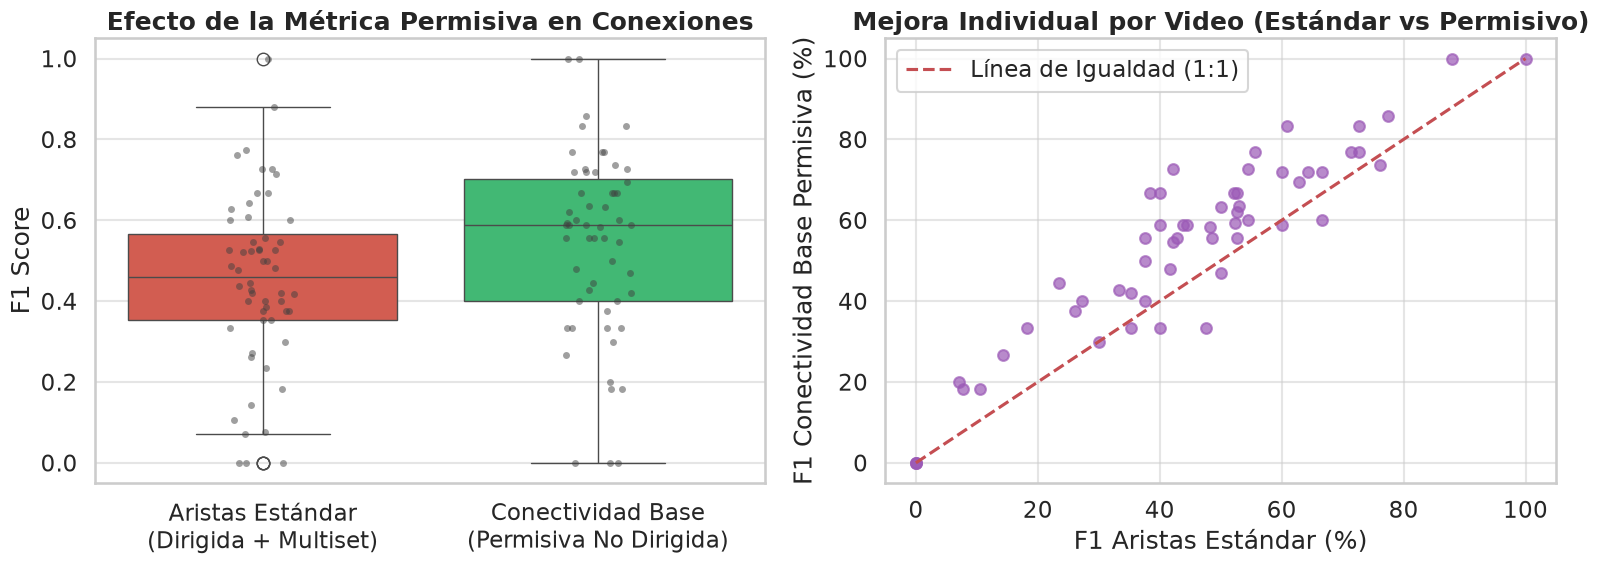


📋 MUESTRA DE RESULTADOS POR VIDEO (Primeros 15):
   video_id  gt_nodes  gen_nodes svc_f1 std_edge_f1 base_edge_f1
-3lnf5lzsH0        13         14  81.8%       60.0%        72.0%
-kA0ahrhX3I         9         11  76.9%        0.0%         0.0%
-wLEkq21cvA         9          9  66.7%       47.6%        33.3%
07lfvavMdfU        10         11  85.7%       66.7%        72.0%
0F7KDLz-kIQ        13         12  81.8%       37.5%        50.0%
1aYoIZvabbk         6          7  22.2%        0.0%         0.0%
1xLjtJnfZes         8          7  80.0%       54.5%        72.7%
2L0m28ZLmtE        13         14  91.7%       64.3%        72.0%
2XVgpMwY5iE         7          8  71.4%       38.5%        66.7%
2e3vOxsHekE         6          6  66.7%       54.5%        60.0%
3WgTBTDlQN8         9         11  70.6%       42.9%        55.6%
3yJZ6rPoZfg         7          8  50.0%       33.3%        42.9%
4-teOQ_dJvY         9          9  57.1%       40.0%        33.3%
5EmA67lSJEs        11         10  80.0% 

In [4]:
# ==========================================
# 🚀 EVALUACIÓN EN LOTE DE TODA LA CARPETA
# ==========================================
CARPETA_OBJETIVO = "data/graphs"  # Opciones: "data/graphs_parsimonious" o "data/graphs"

dir_gen = PROJECT_ROOT / CARPETA_OBJETIVO
dir_gt = PROJECT_ROOT / "data" / "cloudscape_gt"

files_gen = {f.stem: f for f in dir_gen.glob("*.graphml")}
files_gt = {f.stem: f for f in dir_gt.glob("*.graphml")}

matching_vids = sorted(set(files_gen.keys()) & set(files_gt.keys()))

results_list = []
for vid in matching_vids:
    g_gt = nx.read_graphml(str(files_gt[vid]))
    g_gen = nx.read_graphml(str(files_gen[vid]))
    r = evaluate_single_pair(g_gen, g_gt, vid)
    results_list.append(r)

df_results = pd.DataFrame(results_list)
df_valid = df_results[df_results["graph_usable"] == True].copy()

print(f"✅ Evaluación Masiva Completada:")
print(f"   • Carpeta: {CARPETA_OBJETIVO}")
print(f"   • Total Archivos Encontrados: {len(files_gen)}")
print(f"   • Coincidencias con Ground Truth: {len(matching_vids)}")
print(f"   • Grafos Válidos Evaluados (Core Benchmark): {len(df_valid)}")

# Tabla Resumen de Promedios
resumen_promedios = pd.DataFrame({
    "Métrica de Evaluación": [
        "F1 Servicios Únicos (svc_f1)",
        "F1 Nodos Multiset (ms_f1)",
        "F1 Aristas Estándar [Dirigidas Multiset] (std_edge_f1)",
        "F1 Aristas Permisivo [Conectividad Base No Dirigida] (base_edge_f1)"
    ],
    "Promedio (Mean)": [
        df_valid["svc_f1"].mean(),
        df_valid["ms_f1"].mean(),
        df_valid["std_edge_f1"].mean(),
        df_valid["base_edge_f1"].mean()
    ],
    "Mediana (Median)": [
        df_valid["svc_f1"].median(),
        df_valid["ms_f1"].median(),
        df_valid["std_edge_f1"].median(),
        df_valid["base_edge_f1"].median()
    ]
})

resumen_promedios["Promedio (Mean)"] = resumen_promedios["Promedio (Mean)"].apply(lambda x: f"{x:.1%}")
resumen_promedios["Mediana (Median)"] = resumen_promedios["Mediana (Median)"].apply(lambda x: f"{x:.1%}")

print("\n📊 TABLA RESUMEN GLOBAL (ESTÁNDAR VS PERMISIVO):")
print(resumen_promedios.to_string(index=False))

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Comparación Boxplot Estándar vs Permisivo
df_plot_edges = df_valid.melt(
    value_vars=["std_edge_f1", "base_edge_f1"], 
    var_name="Tipo de Métrica", 
    value_name="F1 Score"
)
df_plot_edges["Tipo de Métrica"] = df_plot_edges["Tipo de Métrica"].map({
    "std_edge_f1": "Aristas Estándar\n(Dirigida + Multiset)",
    "base_edge_f1": "Conectividad Base\n(Permisiva No Dirigida)"
})

sns.boxplot(x="Tipo de Métrica", y="F1 Score", hue="Tipo de Métrica", data=df_plot_edges, ax=axes[0], palette=["#e74c3c", "#2ecc71"], legend=False)
sns.stripplot(x="Tipo de Métrica", y="F1 Score", data=df_plot_edges, ax=axes[0], color=".25", alpha=0.5, size=5)
axes[0].set_title("Efecto de la Métrica Permisiva en Conexiones", fontweight="bold")
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_ylabel("F1 Score")
axes[0].set_xlabel("")

# 2. Scatter plot Estándar vs Permisivo por Video
axes[1].scatter(df_valid["std_edge_f1"] * 100, df_valid["base_edge_f1"] * 100, color="#9b59b6", alpha=0.7, s=60)
axes[1].plot([0, 100], [0, 100], "r--", label="Línea de Igualdad (1:1)")
axes[1].set_title("Mejora Individual por Video (Estándar vs Permisivo)", fontweight="bold")
axes[1].set_xlabel("F1 Aristas Estándar (%)")
axes[1].set_ylabel("F1 Conectividad Base Permisiva (%)")
axes[1].set_xlim(-5, 105)
axes[1].set_ylim(-5, 105)
axes[1].legend()

plt.tight_layout()
plt.show()

# Mostrar DataFrame detallado de videos
print("\n📋 MUESTRA DE RESULTADOS POR VIDEO (Primeros 15):")
cols_view = ["video_id", "gt_nodes", "gen_nodes", "svc_f1", "std_edge_f1", "base_edge_f1"]
df_view = df_valid[cols_view].copy()
for col in ["svc_f1", "std_edge_f1", "base_edge_f1"]:
    df_view[col] = df_view[col].apply(lambda x: f"{x:.1%}")
print(df_view.head(15).to_string(index=False))

## 🔬 3. Prompt Evolution — Análisis de Patrones de Error

Analiza los resultados de evaluación existentes (`cloudscape_reports/evaluation_results.json`) para identificar **patrones sistemáticos de error** del modelo.

**Objetivo:** Generar insights accionables para mejorar el prompt del modelo de manera data-driven.

**Outputs:**
- `prompt_evolution_analysis.csv` — Tabla por servicio con métricas de error
- `edge_confusion_matrix.csv` — Pares de aristas confundidos
- `prompt_improvement_rules.md` — Reglas propuestas basadas en patrones
- Visualizaciones de patrones de error

In [5]:
# ==========================================
# 🔬 CARGA Y ANÁLISIS DE PATRONES DE ERROR
# ==========================================

# Cargar resultados completos de evaluación
EVAL_RESULTS_PATH = PROJECT_ROOT / "cloudscape_reports" / "evaluation_results.json"
with open(EVAL_RESULTS_PATH, "r", encoding="utf-8") as f:
    eval_data = json.load(f)

per_video = eval_data["per_video"]
# Filtrar solo grafos usables
usable = [v for v in per_video if v.get("graph_usable", True)]
print(f"📊 Videos totales: {len(per_video)} | Usables: {len(usable)} | Excluidos: {len(per_video) - len(usable)}")

# ══════════════════════════════════════════════════════════════
# 1. ANÁLISIS DE SERVICIOS: ¿Cuáles se olvidan/alucinan más?
# ══════════════════════════════════════════════════════════════
missing_counter = Counter()
hallucinated_counter = Counter()
correct_counter = Counter()
# Conteo de veces que un servicio aparece en GT
gt_appearance_counter = Counter()

for v in usable:
    missing_counter.update(v["services_missing"])
    hallucinated_counter.update(v["services_hallucinated"])
    correct_counter.update(v["services_correct"])
    # Contar apariciones en GT (correct + missing = total GT)
    gt_appearance_counter.update(v["services_correct"])
    gt_appearance_counter.update(v["services_missing"])

# Construir DataFrame por servicio
all_services = set(missing_counter.keys()) | set(hallucinated_counter.keys()) | set(correct_counter.keys())
rows = []
for svc in sorted(all_services):
    gt_count = gt_appearance_counter.get(svc, 0)
    correct = correct_counter.get(svc, 0)
    missed = missing_counter.get(svc, 0)
    halluc = hallucinated_counter.get(svc, 0)
    recall = correct / gt_count if gt_count > 0 else None
    precision = correct / (correct + halluc) if (correct + halluc) > 0 else None
    cap = CATALOG.get(svc, {}).get("capability", "unknown")
    
    rows.append({
        "service": svc,
        "capability": cap,
        "gt_appearances": gt_count,
        "times_correct": correct,
        "times_missed": missed,
        "times_hallucinated": halluc,
        "recall": recall,
        "precision": precision,
        "net_error": halluc - missed,  # Positivo = tiende a alucinar, Negativo = tiende a omitir
    })

df_services = pd.DataFrame(rows)
df_services = df_services.sort_values("times_missed", ascending=False)

print("\n" + "=" * 70)
print("📋 SERVICIOS MÁS PROBLEMÁTICOS (ordenados por veces omitidos)")
print("=" * 70)
display(df_services[df_services["times_missed"] + df_services["times_hallucinated"] > 0].head(20))

# Guardar CSV
svc_csv_path = PROJECT_ROOT / "whiteboard_selection_lab" / "prompt_evolution_analysis.csv"
df_services.to_csv(svc_csv_path, index=False)
print(f"\n✓ Tabla guardada en: {svc_csv_path}")


📊 Videos totales: 63 | Usables: 56 | Excluidos: 7

📋 SERVICIOS MÁS PROBLEMÁTICOS (ordenados por veces omitidos)


,service,capability,gt_appearances,times_correct,times_missed,times_hallucinated,recall,precision,net_error
99,UserConsumerWeb,User,14,3,11,10,0.214286,0.230769,-1
85,UserCompanyDataStream,User,10,1,9,1,0.100000,0.500000,-8
97,UserConsumerMobile,User,12,4,8,2,0.333333,0.666667,-6
25,EC2,compute,20,15,5,5,0.750000,0.750000,0
83,UserCompanyAnalyst,User,6,1,5,7,0.166667,0.125000,2
82,UserCompanyAgent,User,8,3,5,8,0.375000,0.272727,3
92,UserConsumerAPI,User,4,0,4,0,0.000000,NaN,-4
78,ThirdParty,ThirdParty,24,20,4,15,0.833333,0.571429,11
66,S3,storage,35,32,3,0,0.914286,1.000000,-3
0,ALB,networking,7,4,3,0,0.571429,1.000000,-3



✓ Tabla guardada en: /home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/prompt_evolution_analysis.csv


In [6]:
# ══════════════════════════════════════════════════════════════
# 2. PATRONES DE CONFUSIÓN: ¿Qué servicio se confunde con cuál?
# ══════════════════════════════════════════════════════════════

# Analizar los servicios que se alucinan cuando otro está missing
# Hipótesis: si el modelo olvida "UserConsumerWeb", ¿qué pone en su lugar?
confusion_pairs = Counter()

for v in usable:
    missing = set(v["services_missing"])
    hallucinated = set(v["services_hallucinated"])
    
    # Cada par (missing, hallucinated) en el mismo video es una posible confusión
    for m in missing:
        for h in hallucinated:
            # Solo considerar confusiones de la misma capability
            m_cap = CATALOG.get(m, {}).get("capability", "?")
            h_cap = CATALOG.get(h, {}).get("capability", "?")
            if m_cap == h_cap:  # Misma categoría = probable confusión
                confusion_pairs[(m, h)] += 1

print("=" * 70)
print("🔀 PATRONES DE CONFUSIÓN (servicio faltante → servicio alucinado)")
print("   Solo se muestran pares de la misma capability")
print("=" * 70)

confusion_rows = []
for (m, h), count in confusion_pairs.most_common(25):
    cap = CATALOG.get(m, {}).get("capability", "?")
    confusion_rows.append({
        "missing_service": m,
        "hallucinated_instead": h,
        "capability": cap,
        "co_occurrences": count,
    })
    print(f"  {m:25s} → {h:25s} ({cap:10s}) x{count}")

df_confusion = pd.DataFrame(confusion_rows)
conf_csv_path = PROJECT_ROOT / "whiteboard_selection_lab" / "service_confusion_matrix.csv"
df_confusion.to_csv(conf_csv_path, index=False)
print(f"\n✓ Matriz de confusión guardada en: {conf_csv_path}")


🔀 PATRONES DE CONFUSIÓN (servicio faltante → servicio alucinado)
   Solo se muestran pares de la misma capability
  UserConsumerWeb           → UserConsumerWebMobile     (User      ) x6
  UserConsumerMobile        → UserConsumerWebMobile     (User      ) x4
  UserCompanyDeveloper      → UserConsumerWeb           (User      ) x3
  UserConsumerWeb           → UserCompanyAgent          (User      ) x3
  UserConsumerMobile        → UserCompanyAnalyst        (User      ) x3
  UserCompanyAnalyst        → UserConsumerWeb           (User      ) x2
  UserCompanyDataStream     → UserConsumerHospital      (User      ) x2
  Kinesis                   → KinesisDataStream         (integration) x2
  UserConsumerWeb           → UserCompanyAnalyst        (User      ) x2
  UserCompanyAgent          → UserConsumerWeb           (User      ) x1
  MediaConvert              → Lambda                    (compute   ) x1
  Fargate                   → ECS                       (compute   ) x1
  UserCompanyDataStre

In [7]:
# ══════════════════════════════════════════════════════════════
# 3. ANÁLISIS DE ERRORES EN ARISTAS
# ══════════════════════════════════════════════════════════════

edges_missing_counter = Counter()   # Aristas que faltan (están en GT pero no en gen)
edges_halluc_counter = Counter()    # Aristas alucinadas (están en gen pero no en GT)

for v in usable:
    for edge_str, count in v.get("edges_only_gt", {}).items():
        edges_missing_counter[edge_str] += count
    for edge_str, count in v.get("edges_only_gen", {}).items():
        edges_halluc_counter[edge_str] += count

print("=" * 70)
print("🔴 ARISTAS MÁS FRECUENTEMENTE OMITIDAS (en GT pero no en generado)")
print("=" * 70)
for edge, count in edges_missing_counter.most_common(15):
    print(f"  {edge:40s} x{count}")

print(f"\n{'=' * 70}")
print("🟡 ARISTAS MÁS FRECUENTEMENTE ALUCINADAS (en generado pero no en GT)")
print("=" * 70)
for edge, count in edges_halluc_counter.most_common(15):
    print(f"  {edge:40s} x{count}")

# Aristas bidireccionales: ¿El modelo crea pares A→B y B→A cuando el GT solo tiene uno?
print(f"\n{'=' * 70}")
print("🔁 ARISTAS BIDIRECCIONALES ALUCINADAS")
print("   (el modelo genera A→B y B→A, pero solo uno existe en GT)")
print("=" * 70)
bidi_count = 0
for edge_str in edges_halluc_counter:
    parts = edge_str.split("→")
    if len(parts) == 2:
        reverse = f"{parts[1]}→{parts[0]}"
        if reverse in edges_missing_counter or reverse not in edges_halluc_counter:
            # Podría ser un edge de retorno innecesario
            if edge_str in edges_halluc_counter and edges_halluc_counter[edge_str] >= 2:
                print(f"  {edge_str:40s} (alucinado x{edges_halluc_counter[edge_str]})")
                bidi_count += 1
if bidi_count == 0:
    print("  (No se detectaron patrones claros de bidireccionalidad innecesaria)")


🔴 ARISTAS MÁS FRECUENTEMENTE OMITIDAS (en GT pero no en generado)
  DynamoDB→Lambda                          x7
  S3→EC2                                   x6
  CloudFront→UserConsumerWeb               x5
  EC2→S3                                   x5
  Lambda→S3                                x5
  EC2→ThirdParty                           x4
  S3→Athena                                x4
  UserCompanyAgent→ThirdParty              x4
  UserConsumerWeb→CloudFront               x4
  S3→CloudFront                            x4
  EKS→EKS                                  x4
  ThirdParty→Lambda                        x4
  Lambda→ApiGateway                        x4
  UserCompanyDataStream→S3                 x3
  Lambda→EC2                               x3

🟡 ARISTAS MÁS FRECUENTEMENTE ALUCINADAS (en generado pero no en GT)
  ThirdParty→ThirdParty                    x24
  ThirdParty→S3                            x6
  Lambda→ThirdParty                        x6
  UserConsumerWebMobile→CloudFront  

📊 RENDIMIENTO POR CAPABILITY (de peor a mejor)


,capability,gt_count,correct,missed,hallucinated,recall,precision,f1
0,OnPremDC,1,0,1,2,0.000000,0.000000,0.000000
3,User,75,18,57,56,0.240000,0.243243,0.241611
2,ThirdParty,24,20,4,15,0.833333,0.571429,0.677966
1,Partner,2,2,0,1,1.000000,0.666667,0.800000
5,control,24,22,2,7,0.916667,0.758621,0.830189
8,other,21,18,3,3,0.857143,0.857143,0.857143
6,integration,37,31,6,3,0.837838,0.911765,0.873239
7,networking,47,41,6,5,0.872340,0.891304,0.881720
4,compute,108,95,13,12,0.879630,0.887850,0.883721
9,storage,82,79,3,2,0.963415,0.975309,0.969325


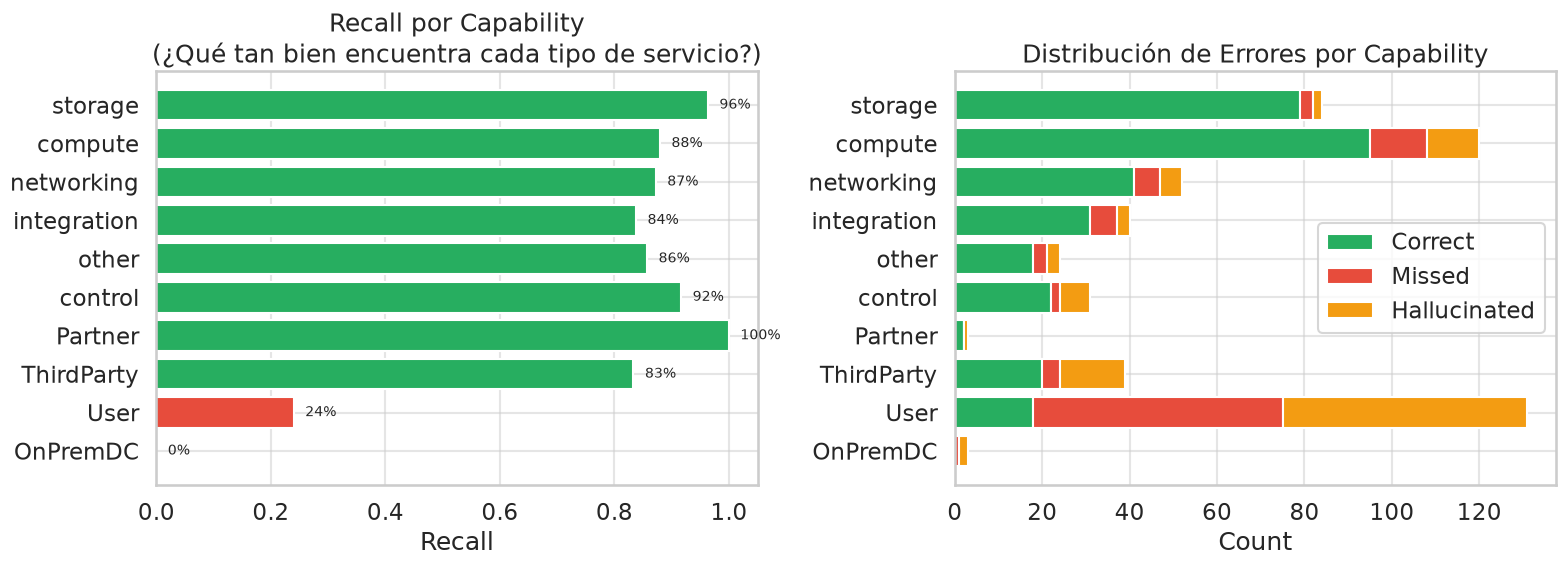

✓ Gráfica guardada en: whiteboard_selection_lab/capability_error_analysis.png


In [8]:
# ══════════════════════════════════════════════════════════════
# 4. RENDIMIENTO POR CAPABILITY (¿En qué tipo de servicio falla más?)
# ══════════════════════════════════════════════════════════════

cap_data = eval_data["summary"]["capability_breakdown"]

cap_rows = []
for cap, vals in sorted(cap_data.items()):
    gt = vals.get("gt", 0)
    correct = vals.get("correct", 0)
    missed = vals.get("missed", 0)
    halluc = vals.get("hallucinated", 0)
    recall = correct / gt if gt > 0 else 0
    precision = correct / (correct + halluc) if (correct + halluc) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    cap_rows.append({
        "capability": cap,
        "gt_count": gt,
        "correct": correct,
        "missed": missed,
        "hallucinated": halluc,
        "recall": recall,
        "precision": precision,
        "f1": f1,
    })

df_cap = pd.DataFrame(cap_rows).sort_values("f1")

print("=" * 70)
print("📊 RENDIMIENTO POR CAPABILITY (de peor a mejor)")
print("=" * 70)
display(df_cap)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: Recall por capability
colors = ['#e74c3c' if r < 0.5 else '#f39c12' if r < 0.8 else '#27ae60' for r in df_cap['recall']]
axes[0].barh(df_cap['capability'], df_cap['recall'], color=colors)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel('Recall')
axes[0].set_title('Recall por Capability\n(¿Qué tan bien encuentra cada tipo de servicio?)')
for i, (r, cap) in enumerate(zip(df_cap['recall'], df_cap['capability'])):
    axes[0].text(r + 0.02, i, f'{r:.0%}', va='center', fontsize=10)

# Stacked bar: Correct vs Missed vs Hallucinated
x = range(len(df_cap))
axes[1].barh(df_cap['capability'], df_cap['correct'], color='#27ae60', label='Correct')
axes[1].barh(df_cap['capability'], df_cap['missed'], left=df_cap['correct'], color='#e74c3c', label='Missed')
axes[1].barh(df_cap['capability'], df_cap['hallucinated'], left=df_cap['correct'] + df_cap['missed'], color='#f39c12', label='Hallucinated')
axes[1].set_xlabel('Count')
axes[1].set_title('Distribución de Errores por Capability')
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'whiteboard_selection_lab' / 'capability_error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfica guardada en: whiteboard_selection_lab/capability_error_analysis.png")


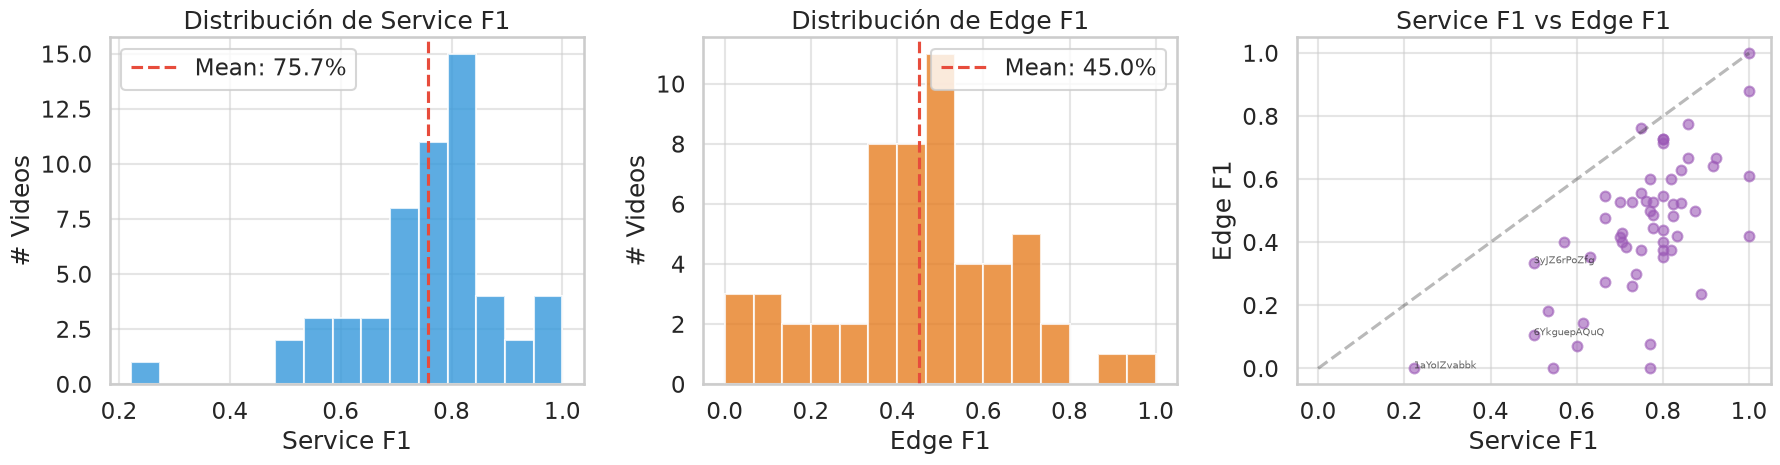


⚠️  TOP 10 VIDEOS CON PEOR RENDIMIENTO


,video_id,svc_f1,edge_f1,gen_nodes,gt_nodes,services_missing,services_hallucinated
5,1aYoIZvabbk,22.2%,0.0%,7,6,"ALB, EKS, SNS, SQS, UserCompanyDeveloper","ThirdParty, UserConsumerWeb"
11,3yJZ6rPoZfg,50.0%,33.3%,8,7,"EC2, UserConsumerEdge, VPC","AutoScaling, UserConsumerWebMobile, VPCPeering"
19,6YkguepAQuQ,50.0%,10.5%,10,10,"ALB, ECR, ECS, IAM, UserCompanyDeveloper, VPC","ThirdParty, UserConsumerWeb"
40,LYP98nPBj2A,53.3%,18.2%,16,5,—,"CloudWatch, Macie, SecurityHub, ThirdParty, Us..."
24,Cgv0kfp_6xQ,54.5%,0.0%,11,10,"EKS, S3, UserConsumerMobile","ThirdParty, UserConsumerWeb"
12,4-teOQ_dJvY,57.1%,40.0%,9,9,"Kinesis, UserCompanyAPI, UserCompanyEdge","KinesisDataStream, ThirdParty, UserCompanyInte..."
55,ww5fiygF6eg,60.0%,7.1%,8,10,"Lambda, S3, StorageGateway, UserCompanyDrone",—
28,DAJZAygxDZA,61.5%,14.3%,9,8,"ModelRegistry, UserCompanyAnalyst","ApiGateway, StepFunctions, UserCompanyDomainEx..."
38,KywvGM6HVXI,63.2%,35.3%,13,11,"EC2, Kinesis, UserConsumerWeb","EKS, KinesisDataStream, ThirdParty, UserConsum..."
2,-wLEkq21cvA,66.7%,47.6%,9,9,"AppDiscovery, UserCompanyAgent",UserConsumerWeb


In [9]:
# ══════════════════════════════════════════════════════════════
# 5. DISTRIBUCIÓN DE SCORES Y CASOS PEORES
# ══════════════════════════════════════════════════════════════

df_videos = pd.DataFrame(usable)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma de Service F1
axes[0].hist(df_videos['svc_f1'], bins=15, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df_videos['svc_f1'].mean(), color='#e74c3c', linestyle='--', label=f"Mean: {df_videos['svc_f1'].mean():.1%}")
axes[0].set_xlabel('Service F1')
axes[0].set_ylabel('# Videos')
axes[0].set_title('Distribución de Service F1')
axes[0].legend()

# Histograma de Edge F1
axes[1].hist(df_videos['edge_f1'], bins=15, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].axvline(df_videos['edge_f1'].mean(), color='#e74c3c', linestyle='--', label=f"Mean: {df_videos['edge_f1'].mean():.1%}")
axes[1].set_xlabel('Edge F1')
axes[1].set_ylabel('# Videos')
axes[1].set_title('Distribución de Edge F1')
axes[1].legend()

# Scatter: Service F1 vs Edge F1
axes[2].scatter(df_videos['svc_f1'], df_videos['edge_f1'], alpha=0.6, s=50, c='#9b59b6')
axes[2].set_xlabel('Service F1')
axes[2].set_ylabel('Edge F1')
axes[2].set_title('Service F1 vs Edge F1')
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
# Anotar los peores casos
worst = df_videos.nsmallest(3, 'svc_f1')
for _, row in worst.iterrows():
    axes[2].annotate(row['video_id'][:11], (row['svc_f1'], row['edge_f1']),
                     fontsize=7, alpha=0.7)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'whiteboard_selection_lab' / 'score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de los 10 peores videos
print("\n" + "=" * 70)
print("⚠️  TOP 10 VIDEOS CON PEOR RENDIMIENTO")
print("=" * 70)
worst_10 = df_videos.nsmallest(10, 'svc_f1')[[
    'video_id', 'svc_f1', 'edge_f1', 'gen_nodes', 'gt_nodes',
    'services_missing', 'services_hallucinated'
]].copy()
worst_10['svc_f1'] = worst_10['svc_f1'].apply(lambda x: f"{x:.1%}")
worst_10['edge_f1'] = worst_10['edge_f1'].apply(lambda x: f"{x:.1%}")
worst_10['services_missing'] = worst_10['services_missing'].apply(lambda x: ', '.join(x) if x else '—')
worst_10['services_hallucinated'] = worst_10['services_hallucinated'].apply(lambda x: ', '.join(x) if x else '—')
display(worst_10)


In [10]:
# ══════════════════════════════════════════════════════════════
# 6. GENERACIÓN AUTOMÁTICA DE REGLAS PARA MEJORAR EL PROMPT
# ══════════════════════════════════════════════════════════════

rules = []
rules.append("# 🔬 Prompt Improvement Rules (Auto-Generated)\n")
rules.append(f"Generated from analysis of {len(usable)} usable video evaluations.\n")
rules.append(f"Overall Model Performance: Svc F1={eval_data['summary']['avg_svc_f1']:.1%}, Edge F1={eval_data['summary']['avg_edge_f1']:.1%}\n")

# Rule 1: Servicios frecuentemente omitidos
rules.append("## 🔴 Regla 1: Servicios Frecuentemente Omitidos\n")
rules.append("El modelo tiende a olvidar estos servicios. Agregar reglas explícitas al prompt.\n")
rules.append("| Servicio | Capability | Veces Omitido | Veces en GT | Miss Rate |")
rules.append("|----------|------------|---------------|-------------|-----------|")
for _, row in df_services[df_services['times_missed'] >= 3].iterrows():
    gt = row['gt_appearances']
    miss_rate = row['times_missed'] / gt if gt > 0 else 0
    rules.append(f"| {row['service']} | {row['capability']} | {row['times_missed']} | {gt} | {miss_rate:.0%} |")
rules.append("")

# Rule 2: Servicios frecuentemente alucinados
rules.append("## 🟡 Regla 2: Servicios Frecuentemente Alucinados\n")
rules.append("El modelo inventa estos servicios con frecuencia. Agregar restricciones al prompt.\n")
rules.append("| Servicio | Capability | Veces Alucinado | Acción Sugerida |")
rules.append("|----------|------------|-----------------|-----------------|")
for _, row in df_services[df_services['times_hallucinated'] >= 3].sort_values('times_hallucinated', ascending=False).iterrows():
    svc = row['service']
    cap = row['capability']
    halluc = row['times_hallucinated']
    # Sugerir acción basada en patrones
    if cap == 'User':
        action = 'Clarificar cuándo usar cada tipo de User actor'
    elif svc == 'ThirdParty':
        action = 'No crear ThirdParty a menos que sea explícitamente on-prem'
    else:
        action = 'Verificar que el servicio aparezca como icono en la pizarra'
    rules.append(f"| {svc} | {cap} | {halluc} | {action} |")
rules.append("")

# Rule 3: Patrones de confusión de User actors
user_missing = df_services[(df_services['capability'] == 'User') & (df_services['times_missed'] > 0)]
user_halluc = df_services[(df_services['capability'] == 'User') & (df_services['times_hallucinated'] > 0)]
if len(user_missing) > 0 or len(user_halluc) > 0:
    rules.append("## 👤 Regla 3: Normalización de User Actors\n")
    rules.append("El modelo tiene problemas significativos con la clasificación de actores/usuarios.\n")
    rules.append("**Problema principal:** Confusión entre tipos de User (Web vs Mobile vs WebMobile vs API).\n")
    rules.append("**Acciones sugeridas:**\n")
    # Detect specific User confusion patterns from confusion_pairs
    user_confusions = [(m, h, c) for (m, h), c in confusion_pairs.most_common() 
                       if CATALOG.get(m, {}).get('capability') == 'User']
    if user_confusions:
        for m, h, c in user_confusions[:10]:
            rules.append(f"- El modelo pone **{h}** cuando debería ser **{m}** ({c} veces)")
    rules.append("")

# Rule 4: Análisis de aristas problemáticas
rules.append("## 🔗 Regla 4: Aristas Problemáticas\n")
top_missing_edges = edges_missing_counter.most_common(10)
top_halluc_edges = edges_halluc_counter.most_common(10)
if top_missing_edges:
    rules.append("**Aristas que el modelo olvida con frecuencia:**\n")
    for edge, count in top_missing_edges:
        rules.append(f"- `{edge}` (omitida {count} veces)")
    rules.append("")
if top_halluc_edges:
    rules.append("**Aristas que el modelo inventa con frecuencia:**\n")
    for edge, count in top_halluc_edges:
        rules.append(f"- `{edge}` (alucinada {count} veces)")
    rules.append("")

# Rule 5: Capability con peor rendimiento
rules.append("## 📉 Regla 5: Capabilities con Peor Rendimiento\n")
worst_caps = df_cap[df_cap['recall'] < 0.7]
if len(worst_caps) > 0:
    for _, row in worst_caps.iterrows():
        rules.append(f"- **{row['capability']}**: Recall={row['recall']:.0%}, ")
        rules.append(f"  {row['missed']} de {row['gt_count']} omitidos, {row['hallucinated']} alucinados")
    rules.append("")
else:
    rules.append("Todas las capabilities tienen recall ≥ 70%.\n")

# Rule 6: Node count ratio analysis
rules.append("## 📊 Regla 6: Balance de Conteo de Nodos\n")
avg_ratio = eval_data['summary']['avg_node_count_ratio']
if avg_ratio > 1.2:
    rules.append(f"**Tendencia:** El modelo genera {avg_ratio:.1%} más nodos que el GT en promedio.")
    rules.append("**Acción:** Reforzar la regla de parsimonia en el prompt.\n")
elif avg_ratio < 0.8:
    rules.append(f"**Tendencia:** El modelo genera {(1-avg_ratio):.0%} menos nodos que el GT.")
    rules.append("**Acción:** El modelo es demasiado conservador, expandir la regla de audio-driven expansion.\n")
else:
    rules.append(f"**OK:** Ratio promedio gen/gt = {avg_ratio:.2f}x (dentro del rango aceptable).\n")

# Guardar reglas
rules_text = "\n".join(rules)
rules_path = PROJECT_ROOT / "whiteboard_selection_lab" / "prompt_improvement_rules.md"
rules_path.write_text(rules_text, encoding="utf-8")
print("✓ Reglas de mejora generadas y guardadas en:")
print(f"  {rules_path}")
print("\n" + "=" * 70)
print(rules_text)


✓ Reglas de mejora generadas y guardadas en:
  /home/stemjara/Projects/AWS-Architecture/whiteboard_selection_lab/prompt_improvement_rules.md

# 🔬 Prompt Improvement Rules (Auto-Generated)

Generated from analysis of 56 usable video evaluations.

Overall Model Performance: Svc F1=75.7%, Edge F1=45.0%

## 🔴 Regla 1: Servicios Frecuentemente Omitidos

El modelo tiende a olvidar estos servicios. Agregar reglas explícitas al prompt.

| Servicio | Capability | Veces Omitido | Veces en GT | Miss Rate |
|----------|------------|---------------|-------------|-----------|
| UserConsumerWeb | User | 11 | 14 | 79% |
| UserCompanyDataStream | User | 9 | 10 | 90% |
| UserConsumerMobile | User | 8 | 12 | 67% |
| EC2 | compute | 5 | 20 | 25% |
| UserCompanyAnalyst | User | 5 | 6 | 83% |
| UserCompanyAgent | User | 5 | 8 | 62% |
| UserConsumerAPI | User | 4 | 4 | 100% |
| ThirdParty | ThirdParty | 4 | 24 | 17% |
| S3 | storage | 3 | 35 | 9% |
| ALB | networking | 3 | 7 | 43% |
| UserCompanyDeveloper | 

In [11]:
# ══════════════════════════════════════════════════════════════
# 7. RESUMEN EJECUTIVO PARA EVOLUCIÓN DEL PROMPT
# ══════════════════════════════════════════════════════════════

print("=" * 70)
print("📋 RESUMEN EJECUTIVO — PROMPT EVOLUTION")
print("=" * 70)

summary = eval_data['summary']

# Métricas actuales
print(f"\n🎯 Métricas Actuales del Modelo:")
print(f"   Service F1 (unique):   {summary['avg_svc_f1']:.1%}")
print(f"   Service F1 (multiset): {summary['avg_ms_f1']:.1%}")
print(f"   Edge F1:               {summary['avg_edge_f1']:.1%}")
print(f"   Edge Type Accuracy:    {summary['avg_edge_type_accuracy']:.1%}")
print(f"   Node Count Ratio:      {summary['avg_node_count_ratio']:.2f}x")

# Problemas principales
print(f"\n⚠️  Problemas Principales Identificados:")

# User actors
user_cap = cap_data.get('User', {})
user_recall = user_cap.get('correct', 0) / user_cap.get('gt', 1)
print(f"   1. User Actors: Recall={user_recall:.0%} — El modelo confunde tipos de User")
print(f"      (Missing: {user_cap.get('missed', 0)}, Hallucinated: {user_cap.get('hallucinated', 0)})")

# Edges
print(f"   2. Edge F1 baja ({summary['avg_edge_f1']:.1%}) — Las conexiones son el punto más débil")

# Top 3 servicios omitidos
top_miss = eval_data['top_missing_services'][:3]
print(f"   3. Servicios más omitidos: {', '.join(f'{s}(x{c})' for s, c in top_miss)}")

# Acciones prioritarias
print(f"\n✅ Acciones Prioritarias para Mejorar el Prompt:")
print(f"   🔴 HIGH:   Clarificar reglas de User Actor normalization")
print(f"   🔴 HIGH:   Reducir alucinaciones de ThirdParty ({hallucinated_counter.get('ThirdParty', 0)} veces)")
print(f"   🟡 MEDIUM: Mejorar reglas de routing de aristas (Edge F1={summary['avg_edge_f1']:.1%})")
print(f"   🟡 MEDIUM: Asegurar que servicios de compute se capturen (EC2 missed {missing_counter.get('EC2', 0)} veces)")
print(f"   🟢 LOW:    Ajustar edge type classification (accuracy={summary['avg_edge_type_accuracy']:.1%})")

print(f"\n📁 Archivos generados:")
print(f"   • prompt_evolution_analysis.csv  — Métricas por servicio")
print(f"   • service_confusion_matrix.csv   — Patrones de confusión")
print(f"   • prompt_improvement_rules.md    — Reglas accionables")
print(f"   • capability_error_analysis.png  — Gráfica de errores por capability")
print(f"   • score_distribution.png         — Distribución de scores")


📋 RESUMEN EJECUTIVO — PROMPT EVOLUTION

🎯 Métricas Actuales del Modelo:
   Service F1 (unique):   75.7%
   Service F1 (multiset): 71.5%
   Edge F1:               45.0%
   Edge Type Accuracy:    71.5%
   Node Count Ratio:      1.17x

⚠️  Problemas Principales Identificados:
   1. User Actors: Recall=24% — El modelo confunde tipos de User
      (Missing: 57, Hallucinated: 56)
   2. Edge F1 baja (45.0%) — Las conexiones son el punto más débil
   3. Servicios más omitidos: UserConsumerWeb(x11), UserCompanyDataStream(x9), UserConsumerMobile(x8)

✅ Acciones Prioritarias para Mejorar el Prompt:
   🔴 HIGH:   Clarificar reglas de User Actor normalization
   🔴 HIGH:   Reducir alucinaciones de ThirdParty (15 veces)
   🟡 MEDIUM: Mejorar reglas de routing de aristas (Edge F1=45.0%)
   🟡 MEDIUM: Asegurar que servicios de compute se capturen (EC2 missed 5 veces)
   🟢 LOW:    Ajustar edge type classification (accuracy=71.5%)

📁 Archivos generados:
   • prompt_evolution_analysis.csv  — Métricas por ser

## 🔬 8. Evaluación Ultra-Permisiva (Agrupación de Usuarios, ThirdParty y Conectividad Base)

Esta sección realiza una evaluación **ultra-permisiva** sobre el lote de 14 videos analizados recientemente:
1. **Normalización de Nodos Permisiva**:
   - Todos los tipos de usuario (`UserConsumerWeb`, `UserCompanyAgent`, `UserConsumerMobile`, etc.) y capabilities `User` se unifican bajo la clase genérica **`User`**.
   - Todos los sistemas externos/on-prem (`ThirdParty`, etc.) y capabilities `ThirdParty` se unifican bajo **`ThirdParty`**.
   - Los servicios AWS (S3, EC2, Lambda, Redshift, etc.) mantienen su verificación de identidad exacta.
2. **Conectividad Base No Dirigida (`perm_edge_f1`)**:
   - Evalúa únicamente la existencia estructural de la **conexión base no dirigida** `(min(Service_A, Service_B), max(Service_A, Service_B))` entre servicios normalizados, eliminando la penalización por dirección de flecha o flujos de retorno duplicados.

In [ ]:
# ==============================================================
# 🧪 EVALUACIÓN ULTRA-PERMISIVA DEL BATCH DE 14 VIDEOS ANALIZADOS
# ==============================================================
import pandas as pd
import networkx as nx
from pathlib import Path
from collections import Counter
from evaluacion_permisiva import evaluate_ultra_permissive_pair, CATALOG

# Lista de 14 videos recientemente analizados
BATCH_VIDEO_IDS = [
    "-3lnf5lzsH0", "-kA0ahrhX3I", "-wLEkq21cvA", "07lfvavMdfU",
    "1aYoIZvabbk", "2L0m28ZLmtE", "2e3vOxsHekE", "6CgqEzyWpeA",
    "6EUknQqaV1w", "6YkguepAQuQ", "BZ32w0SSAoY", "Cgv0kfp_6xQ",
    "wjtSHyENv0I", "ww5fiygF6eg"
]

results_batch = []
for vid in BATCH_VIDEO_IDS:
    path_gt = PROJECT_ROOT / "data" / "cloudscape_gt" / f"{vid}.graphml"
    path_gen = PROJECT_ROOT / "whiteboard_selection_lab" / "lab_workspace" / vid / "test_graph.graphml"
    if not path_gen.exists():
        path_gen = PROJECT_ROOT / "data" / "graphs" / f"{vid}.graphml"
        
    if path_gt.exists() and path_gen.exists():
        g_gt = nx.read_graphml(str(path_gt))
        g_gen = nx.read_graphml(str(path_gen))
        res = evaluate_ultra_permissive_pair(g_gen, g_gt, vid)
        results_batch.append(res)
    else:
        print(f"⚠️ No se encontró GT o Grafo para {vid}")

df_perm = pd.DataFrame(results_batch)

print("=" * 75)
print("📊 RESUMEN EJECUTIVO: EVALUACIÓN ULTRA-PERMISIVA (14 VIDEOS BENCHMARK)")
print("=" * 75)

resumen_perm = pd.DataFrame({
    "Métrica Evaluada": [
        "F1 Servicios Únicos Permisivos (perm_svc_f1)",
        "F1 Nodos Multiset Permisivos (perm_ms_f1)",
        "F1 Conectividad Base No Dirigida (perm_edge_f1)"
    ],
    "Promedio (Mean)": [
        f"{df_perm['perm_svc_f1'].mean():.1%}",
        f"{df_perm['perm_ms_f1'].mean():.1%}",
        f"{df_perm['perm_edge_f1'].mean():.1%}"
    ],
    "Mediana (Median)": [
        f"{df_perm['perm_svc_f1'].median():.1%}",
        f"{df_perm['perm_ms_f1'].median():.1%}",
        f"{df_perm['perm_edge_f1'].median():.1%}"
    ]
})
print(resumen_perm.to_string(index=False))
print("=" * 75)

# Mostrar tabla de detalles por video
df_view_perm = df_perm[["video_id", "gt_nodes", "gen_nodes", "perm_svc_f1", "perm_ms_f1", "perm_edge_f1"]].copy()
for col in ["perm_svc_f1", "perm_ms_f1", "perm_edge_f1"]:
    df_view_perm[col] = df_view_perm[col].apply(lambda x: f"{x:.1%}")

print("\n📋 DETALLE PERMISIVO POR VIDEO:")
display(df_view_perm) if "display" in globals() else print(df_view_perm.to_string(index=False))

# Guardar CSV de resultados permisivos
csv_out = PROJECT_ROOT / "whiteboard_selection_lab" / "permissive_batch_evaluation.csv"
df_perm.to_csv(csv_out, index=False)
print(f"\n✓ Resultados permisivos guardados en: {csv_out}")
